In [1]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os

In [2]:
def make_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [3]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [4]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [33]:
results_folder = wd+'/simulations/effect_of_position_focal_bat_d/store_results/'
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
# # glob.glob(results_folder+"*")
list_of_folder_ids
list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
list_of_folder_ids_array_version= [n[0][1:] for n in list_of_folder_ids_array_version]
list_of_folder_ids_array_version= np.array([(float(n[0])) for n in list_of_folder_ids_array_version])

In [34]:
list_of_folder_ids_array_version

array([1., 2., 3., 4., 5., 6.])

In [14]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))

In [15]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [16]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [17]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [35]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        array_containing_all_simulation_datasets.append(simulation_data)
        iterant+=1

100%|██████████| 600/600 [00:01<00:00, 518.88it/s]
/tmp/ipykernel_120377/2572829610.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 243 ms, sys: 6.38 ms, total: 249 ms
Wall time: 1.36 s
CPU times: user 30.5 ms, sys: 0 ns, total: 30.5 ms
Wall time: 30.7 ms


100%|██████████| 500/500 [00:00<00:00, 1970.80it/s]
/tmp/ipykernel_120377/2572829610.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 190 ms, sys: 5.95 ms, total: 196 ms
Wall time: 504 ms
CPU times: user 26.5 ms, sys: 132 μs, total: 26.6 ms
Wall time: 26.6 ms


100%|██████████| 400/400 [00:00<00:00, 1602.44it/s]
/tmp/ipykernel_120377/2572829610.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


...

100%|██████████| 200/200 [00:00<00:00, 1440.96it/s]
/tmp/ipykernel_120377/2572829610.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 117 ms, sys: 3.64 ms, total: 120 ms
Wall time: 259 ms
CPU times: user 10.7 ms, sys: 4 μs, total: 10.7 ms
Wall time: 10.7 ms


100%|██████████| 100/100 [00:00<00:00, 1302.17it/s]

CPU times: user 88.1 ms, sys: 1.94 ms, total: 90 ms
Wall time: 136 ms
CPU times: user 6.19 ms, sys: 0 ns, total: 6.19 ms
Wall time: 6.21 ms



/tmp/ipykernel_120377/2572829610.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


In [19]:
def making_glob_work_properly(subfolder_to_search):
    wd=os.getcwd(); os.chdir(wd+"/"+subfolder_to_search+'/')
    set_of_h5_files= glob.glob("*")
    os.chdir(wd)
    return set_of_h5_files


In [12]:
if what_to_do == 'reanalyse':
    # show all datasets in the folder
    data_stores_in_folder = glob.glob(task_type+'_*]')
    datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
    print(datastores_by_index)
    # user-inputs dataset choice:
    which_dataset = int(input('Give the index of the dataset you want to'))
    print()
    # load a pre-exisiting dataset
    #load the saved data 
    list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
    # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
    array_containing_all_simulation_datasets = []

    for h5_file in list_of_h5_files_in_folder:
        data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
        simulation_data = data_load['simulation_data']
        array_containing_all_simulation_datasets.append(simulation_data)
        data_load.close()
else:
    raise IOError('Invalid input given!!')


OSError: Invalid input given!!

In [ ]:
# list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
# list_of_folder_ids_array_version= [(n[0][1:], n[1][:-1]) for n in list_of_folder_ids_array_version]
# list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

# true_false_indices= list_of_folder_ids_array_version[:,1]==list_of_folder_ids_array_version[0,1]

In [20]:
def passing_true_false_indices_through_lists(list, true_false_list):
    """this is required since list doeesnt support numpy operations and non linear lists can hence not take in true false as indices"""
    output_array= []; iterant=0
    for entry in true_false_list:
        if entry:
            output_array.append(list[iterant])

        iterant+=1
    return output_array

In [21]:
array_containing_all_simulation_datasets

[     nbrs_detected  group_size  group_diameter  \
 0                0          75        6.230421   
 1                1          50        4.981919   
 2                4          20        3.272886   
 3                2          10        2.162181   
 4                6          20        2.892747   
 ..             ...         ...             ...   
 595              1          50        5.054427   
 596              5          10        2.047123   
 597              5          10        1.862546   
 598              2          10        2.070502   
 599              2          50        5.091071   
 
                             nearest_neighbour_distance  \
 0    [0.5333683537396854, 0.683050325597081, 0.6852...   
 1    [0.5004686061138323, 0.5573762720558951, 0.739...   
 2    [0.5231688479704542, 0.5847631595531952, 0.624...   
 3    [0.5239406747654678, 0.5491459470384369, 0.686...   
 4    [0.5291100437394753, 0.6112973857554157, 0.671...   
 ..                             

In [40]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:])
list_containing_simulated_data_sorted_by_nd= {}
for angle in unique_angles_in_dataset:
    list_containing_simulated_data_sorted_by_nd[angle]= []
    sublist_true_false_labels= list_of_folder_ids_array_version[:]==angle
    sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_nd[angle].append(sublist_given_angle)

In [41]:
list_containing_simulated_data_sorted_by_nd

{1.0: [[     nbrs_detected  group_size  group_diameter  \
   0                3           5        1.215726   
   1                0          50        4.952019   
   2                4          30        3.883056   
   3                1          75        6.231253   
   4                1          50        5.209094   
   ..             ...         ...             ...   
   595              4           5        1.453366   
   596              3          30        3.984938   
   597              0           5        1.312572   
   598              7          20        3.003427   
   599              0          20        3.142375   
   
                               nearest_neighbour_distance  \
   0    [0.5437933086160285, 0.586695980341563, 1.0096...   
   1    [0.5753586486525399, 0.726153370854877, 0.7347...   
   2    [0.5026040431025348, 0.5099004573179153, 0.560...   
   3    [0.5554167997915752, 0.6039344291570315, 0.770...   
   4    [0.5282621994236487, 0.7280755958972405, 0

In [42]:
for subset_given_angle in list_containing_simulated_data_sorted_by_nd:
    subset= list_containing_simulated_data_sorted_by_nd[subset_given_angle]
    for item in subset:
        subset

In [43]:
type(simulation_data["group_size"][0])

numpy.int64

1.0


/tmp/ipykernel_120377/3501779479.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


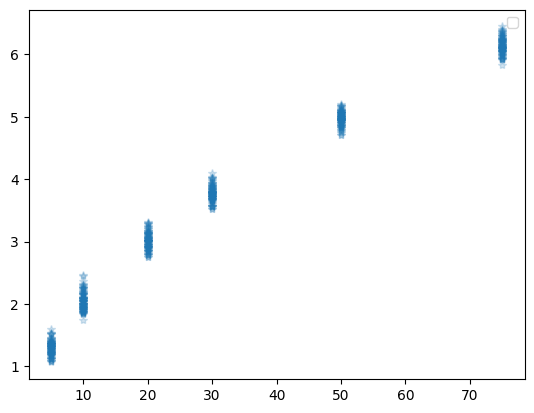

2.0


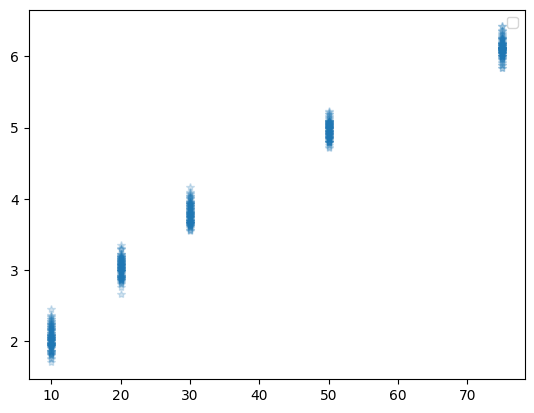

3.0


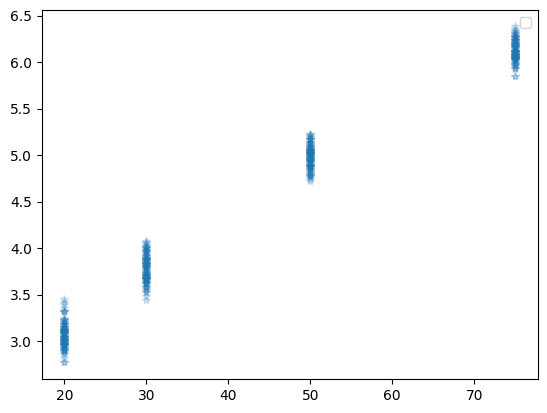

4.0


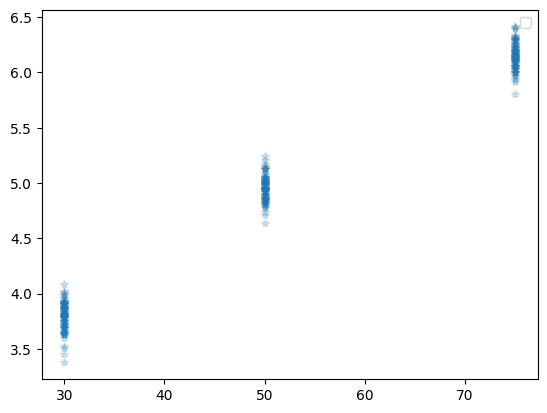

5.0


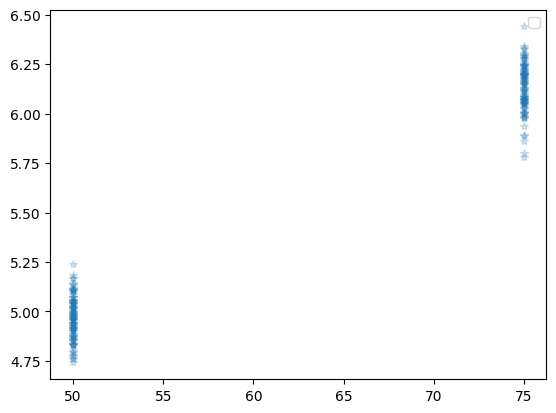

6.0


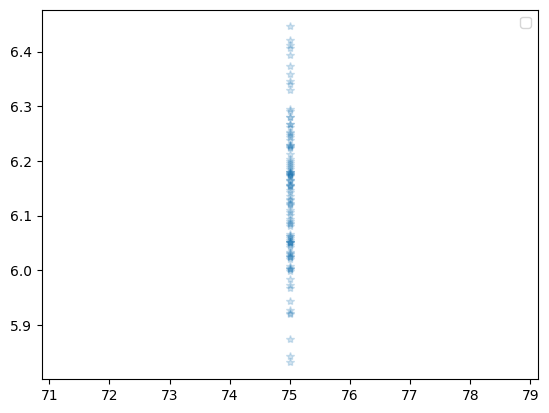

In [44]:
%matplotlib inline
i=0
for angle in list_containing_simulated_data_sorted_by_nd.keys():
    subset_given_angle= list_containing_simulated_data_sorted_by_nd[angle][0]
    print(angle)
    for simulation_data in subset_given_angle:
        plt.plot(simulation_data['group_size'],
                    simulation_data['group_diameter'], 
                '*',label="",alpha=0.2)
        i+=1
        plt.legend()
        plt.show()

In [ ]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [46]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

In [45]:
simulation_data["focal_bat"]

0     6.0
1     6.0
2     6.0
3     6.0
4     6.0
     ... 
95    6.0
96    6.0
97    6.0
98    6.0
99    6.0
Name: focal_bat, Length: 100, dtype: float64

/tmp/ipykernel_120377/2713174110.py:16: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_120377/2713174110.py:16: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_120377/2713174110.py:16: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_120377/2713174110.py:16: FutureWarning: In a future version o

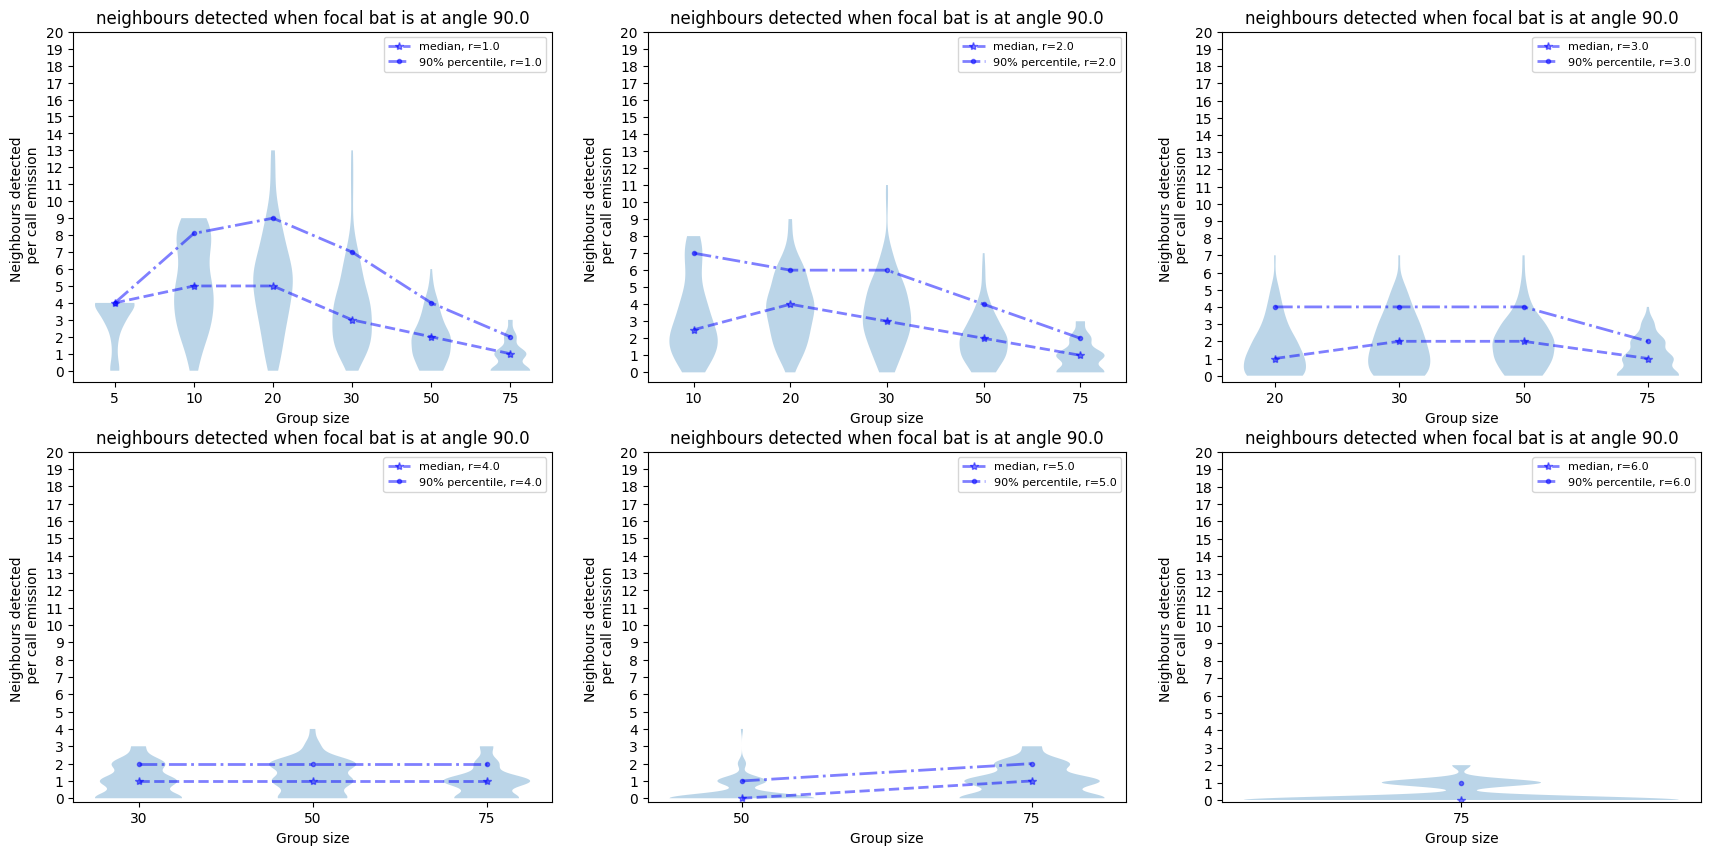

In [60]:
iterant1_axis=0
# fig, axs = plt.subplots(1,3, figsize=(27,9))
plt.figure(figsize=(21,10))
i=1
for angle in list_containing_simulated_data_sorted_by_nd.keys():
        subset_given_angle= list_containing_simulated_data_sorted_by_nd[angle][0]; iterant2_color=0
        colors=["blue", "red", "green", "black"]
        
        for simulation_data in subset_given_angle:
                data_by_groupsize = simulation_data.groupby(['group_size'])
                nbrs_detected_data = {}
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                groupsizes= []
                for groupsize, dataframe in data_by_groupsize:
                        groupsizes.append(groupsize)
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                nbrs_detected_data['median_num_nbrs']

                # plt.figure(figsize=(7,3.42))
                plt.subplot(2,3,i)
                plt.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
                plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
                        '--*',linewidth=2, alpha=0.5,label="median, r="+str(simulation_data["focal_bat"][0]), color= colors[iterant2_color])#'median')
                # print(np.arange(1,len(groupsizes)))
                plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                        '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(simulation_data["focal_bat"][0]), color= colors[iterant2_color])#label='90%ile')
                # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
                plt.yticks(np.arange(0,21,1))
                plt.xticks(range(1,len(groupsizes)+1),groupsizes[:])
                plt.legend(fontsize=8)
                plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
                plt.xlabel('Group size', fontsize=10)
                # # plt.ylim(0,20)

                # axs[i].tight_layout()
                plt.title("neighbours detected when focal bat is at angle "+str(np.degrees(np.pi/2)))
                iterant2_color+=1; i+=1
                
        iterant1_axis+=1
                # plt.savefig('Figure2_groupsize_1200dpi.pdf',
                #         bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)
        
        # print(groupsizes); print(nbrs_detected_data['median_num_nbrs'])

# Verticle transect

moving from $(0.75, \frac {3pi}{2})$ to $(0.75, \frac {pi}{2})$ [r, theta] is similar to moving in a ($x=0$) transect centered at the centermost bat.
Note: All the heading vectors are in 90 degree direction ( $\pm$ 10 degree)

In [54]:
transect_subsets= [[0.75, 3*np.pi/2],[0.5, 3*np.pi/2],[0.2, 3*np.pi/2],[0.0,0.0], [0.2, np.pi/2],[0.5, np.pi/2], [0.75, np.pi/2]]
iterant_transect=0
sublist_of_simulation_data_intransect=[]
for r_theta in transect_subsets:
    for simulation_data in array_containing_all_simulation_datasets:
        if (simulation_data["focal_bat"][0]==r_theta).all():
            sublist_of_simulation_data_intransect.append(simulation_data)
sublist_true_false_labels            

array([False, False, False, False, False,  True])

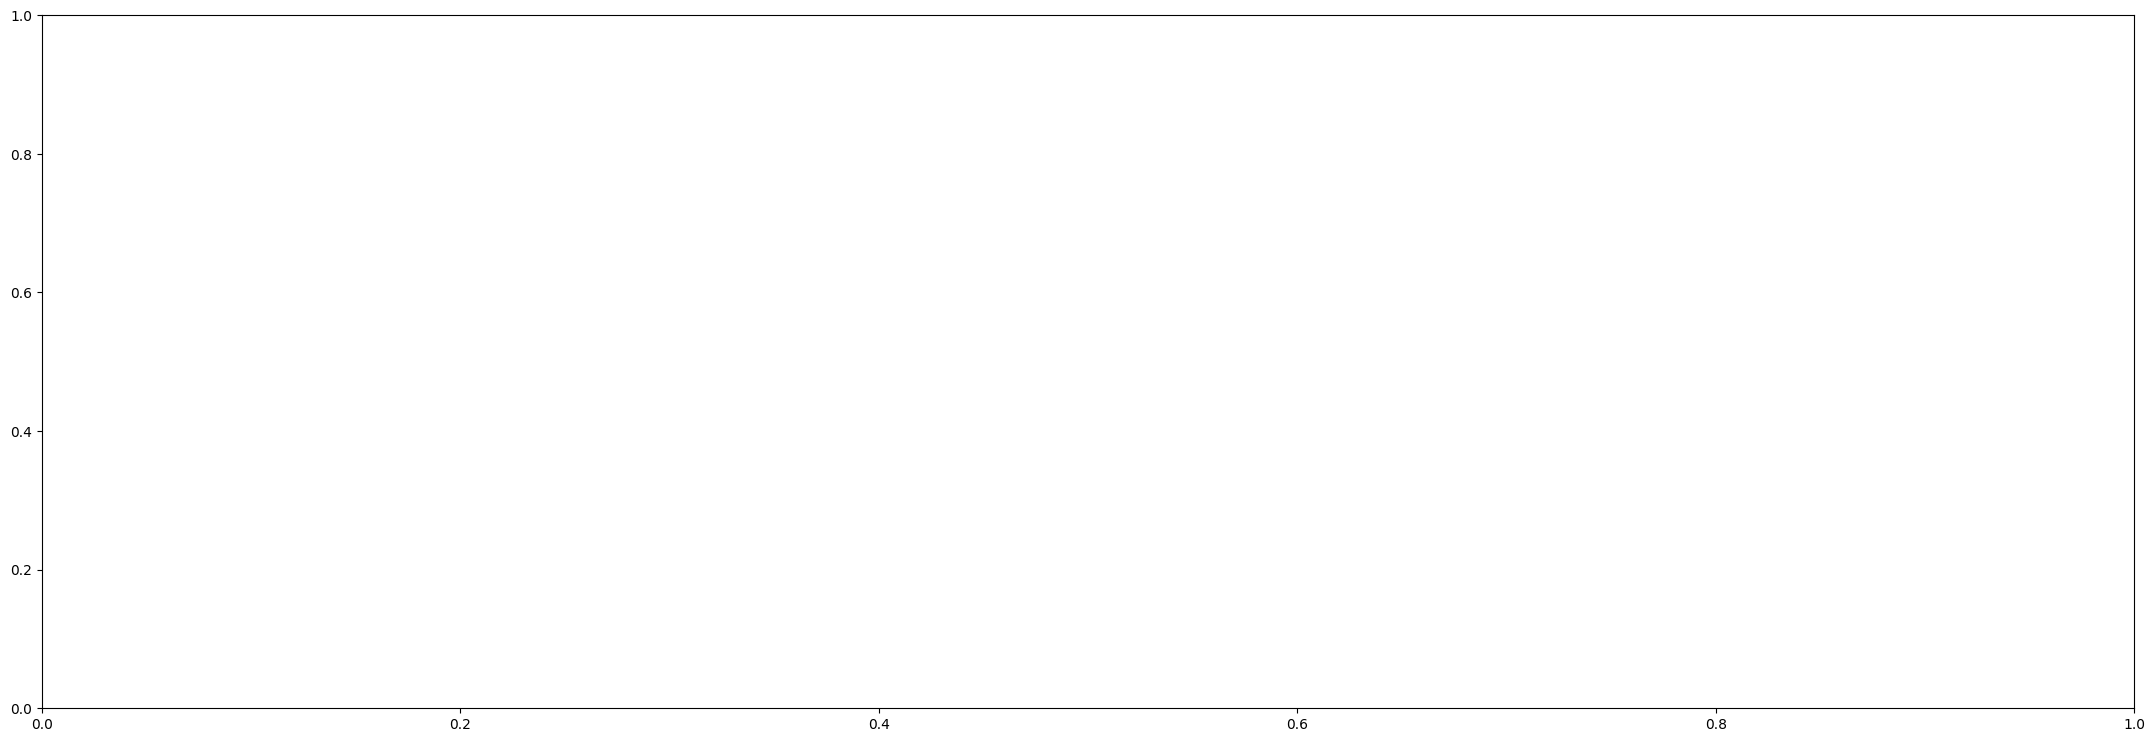

In [55]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, 0, 1, 1, 1]
fig, axs = plt.subplots(1,1, figsize=(27,9))
iterant2_color=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []
        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

        breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
        nbrs_detected_data['median_num_nbrs']

        # plt.figure(figsize=(7,3.42))
        # plt.subplot(1,2,i)
        axs.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
        # axs.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
        #         '--*',linewidth=2, alpha=0.5,label="median, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0]), 
        #         color= colors[iterant2_color])#'median')
        # print(np.arange(1,len(groupsizes)))
        axs.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0])
                , color= colors[iterant2_color])#label='90%ile')
        # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
        axs.set_yticks(np.arange(0,21,1))
        axs.set_xticks(range(1,len(groupsizes)+1),groupsizes[:])
        axs.legend(fontsize=12)
        axs.set_ylabel('Neighbours detected \n per call emission', fontsize=10)
        axs.set_xlabel('Group size', fontsize=10)
        # # plt.ylim(0,20)

        # axs[i].tight_layout()
        axs.set_title("neighbours detected when focal bat is at angle "+str(np.degrees(simulation_data["focal_bat"][0][1])))
        iterant2_color+=1

separate the violin plots out for different group sizes to see clear differences between distance from center


ValueError: zero-size array to reduction operation minimum which has no identity

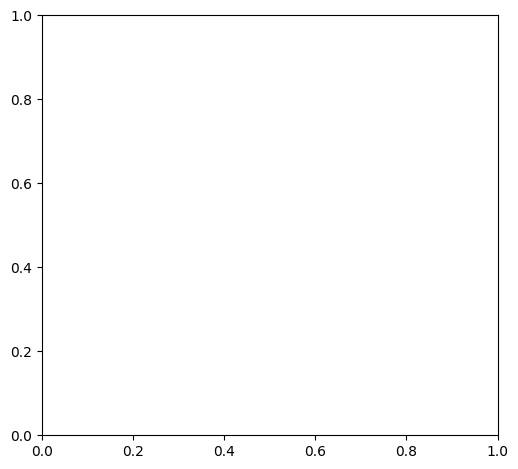

In [56]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, 0, 1, 1, 1]

group_sizes= [5,10,20,30,50,75]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.floor(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=0
    for simulation_data in sublist_of_simulation_data_intransect:
        dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
        
        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])

        iterant_sign+=1

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,8),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

Zooming into the plots to see finer differences between the diffrent violin plots

/tmp/ipykernel_9950/618186438.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize= "8")
/tmp/ipykernel_9950/618186438.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize= "8")
/tmp/ipykernel_9950/618186438.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize= "8")
/tmp/ipykernel_9950/618186438.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize= "8")
/tmp/ipykernel_9950/618186438.py:37: UserWarning: No artists

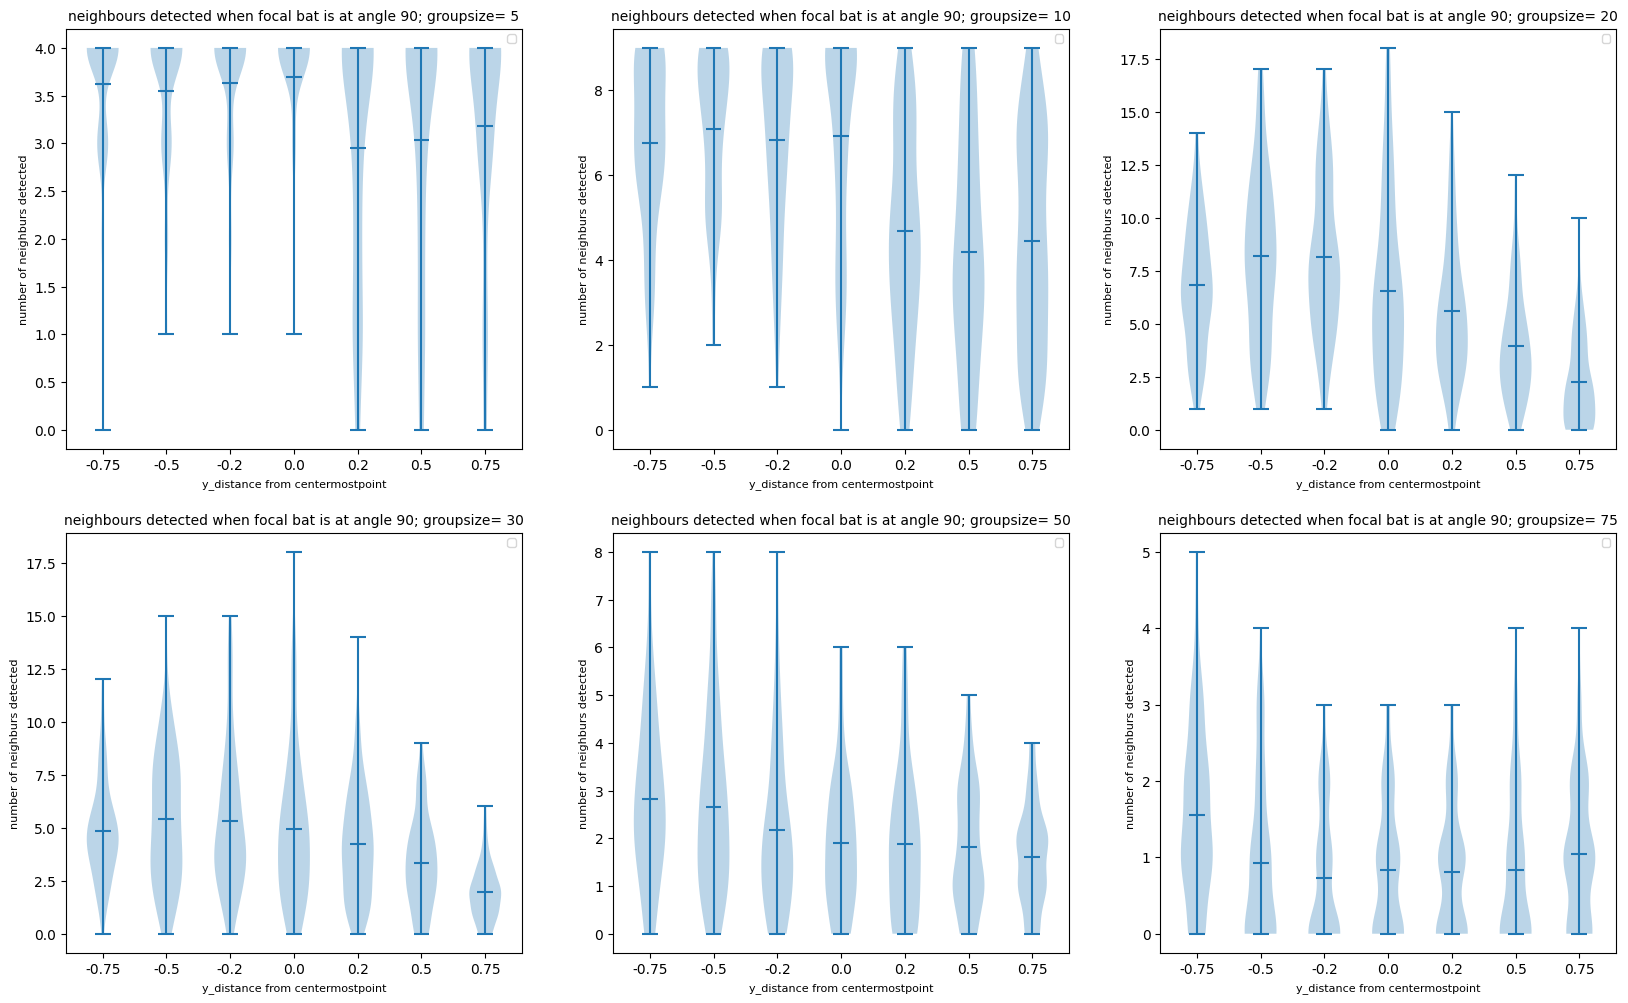

In [ ]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
sign_based_on_distance_from_centermost_point= [-1, -1, -1, 0, 1, 1, 1]

group_sizes= [5,10,20,30,50,75]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.floor(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=0
    for simulation_data in sublist_of_simulation_data_intransect:
        dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
        
        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])

        iterant_sign+=1

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,8),x_ticks)
    # plt.show()
    # plt.ylim(0,group_size+0.5)
    # plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

general trend, having more bats ahead of you is better( ahead is defined by your personal heading direction)

- for large group sizes the change in focal bat distance doesnt matter as much
- for smaller group sizes, -0.75, -0.5, -0.2 and 0 are no different from one another but even slight increase from 0 leads to reduction of total detected neighbours (DO THE STATS)
- idk what else for now